# EDA — Transaksi Nasabah

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

DATA_DIR = '../../../data/ae_3pct'

df_trx = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_nas = pd.read_csv(f'{DATA_DIR}/df_nasabah.csv')

print(f'Transaksi : {df_trx.shape}')
print(f'Nasabah   : {df_nas.shape}')
df_trx.head(3)

Transaksi : (272272, 15)
Nasabah   : (500, 14)


,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,kategori_besar,kategori_detail,label_anomali,gt_kategori_besar,gt_kategori_detail,phase
0,TRX-14110,USR-214,2026-01-01 00:03:00,Debit,NASI PADANG SEDERHANA,-,5812,"33,822.8","5,363,648.1",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong,train
1,TRX-12291,USR-471,2026-01-01 00:04:00,Debit,WARTEG,-,5812,"14,393.8","8,388,854.1",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong,train
2,TRX-12593,USR-454,2026-01-01 00:09:00,Debit,MIE AYAM ABANG,-,5814,"12,677.2","9,556,078.6",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong,train


In [18]:
df = df_trx.copy()
df['tanggal']    = df['timestamp'].dt.date
df['minggu_num'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['hari_nama']  = df['timestamp'].dt.day_name()
df               = df.dropna(subset=['kategori_detail', 'kategori_besar'])

df_debit       = df[df['tipe_mutasi'] == 'Debit'].copy()
KATEGORI_ORDER = sorted(df_debit['kategori_detail'].unique())

df_debit['hour']     = df_debit['timestamp'].dt.hour
df_debit['hour_sin'] = np.sin(2 * np.pi * df_debit['hour'] / 24)
df_debit['hour_cos'] = np.cos(2 * np.pi * df_debit['hour'] / 24)

_le = LabelEncoder()
df_debit['kategori_detail_encoded'] = _le.fit_transform(df_debit['kategori_detail']).astype(float)

print(f'Transaksi Debit : {len(df_debit):,}')
print(f'Rentang tanggal : {df["tanggal"].min()}  –  {df["tanggal"].max()}')
print(f'Kategori ({len(KATEGORI_ORDER)}) :', KATEGORI_ORDER)

Transaksi Debit : 267,492
Rentang tanggal : 2026-01-01  –  2026-06-29
Kategori (10) : ['Belanja Online & Fashion', 'F&B dan Nongkrong', 'Groceries & Kebutuhan Pokok', 'Hiburan & Langganan', 'Investasi & Finansial', 'Kesehatan & Perawatan Diri', 'Produktivitas & Digital', 'Tagihan & Utilitas', 'Transfer P2P', 'Transportasi']


## 1. Distribusi Nominal Harian per Kategori

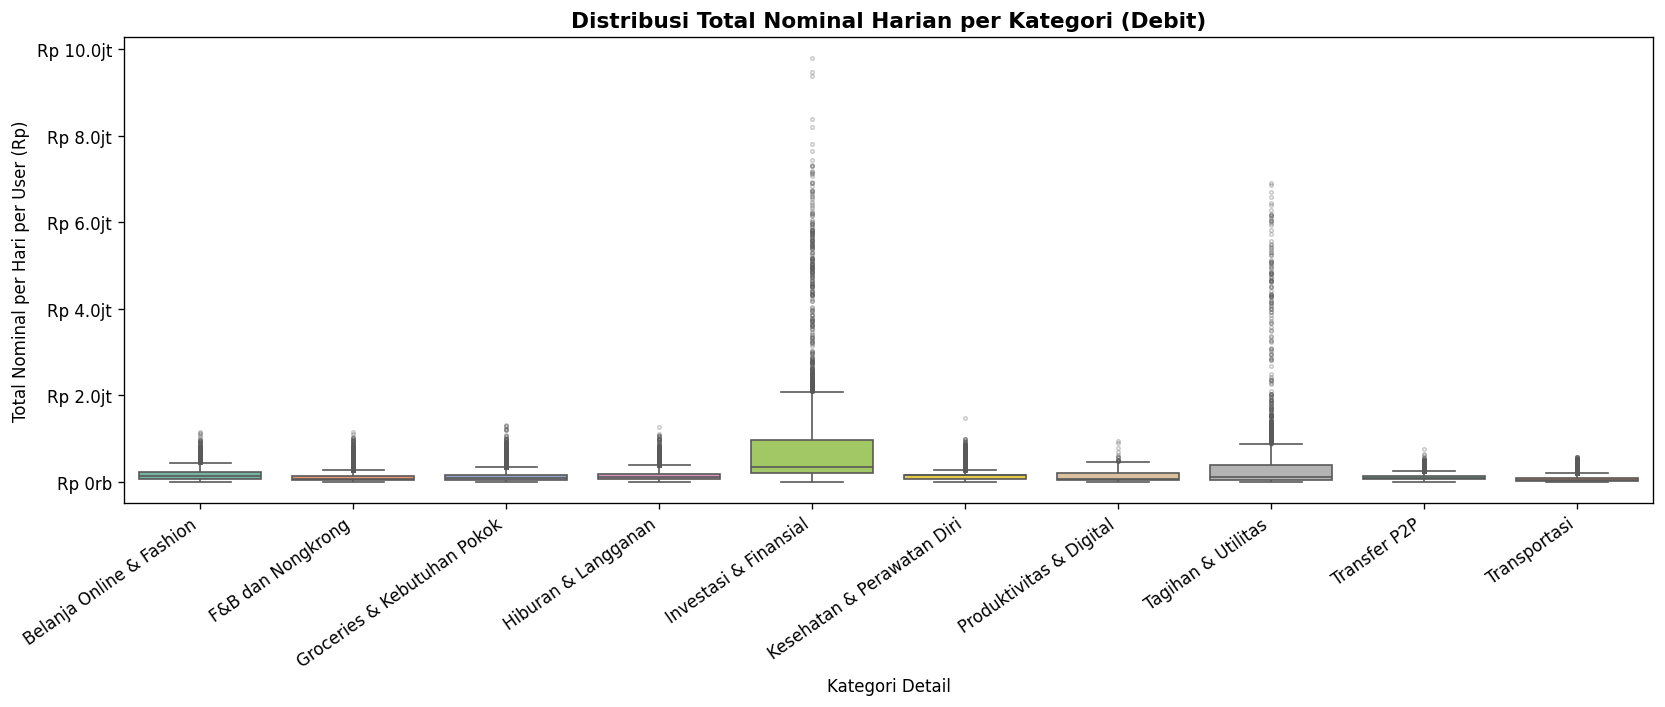

,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"6,311.0","164,501.0","140,856.0","2,000.0","68,185.0","129,586.0","218,215.0","443,510.0","1,158,867.0"
F&B dan Nongkrong,"40,498.0","95,775.0","102,370.0","2,000.0","29,042.0","64,362.0","123,160.0","300,978.0","1,138,031.0"
Groceries & Kebutuhan Pokok,"26,014.0","118,198.0","123,952.0","2,000.0","38,999.0","75,292.0","154,561.0","369,424.0","1,302,883.0"
Hiburan & Langganan,"14,781.0","141,145.0","121,566.0","2,000.0","56,100.0","101,683.0","186,000.0","381,376.0","1,259,193.0"
Investasi & Finansial,"4,029.0","813,006.0","1,173,635.0",149.0,"208,000.0","345,613.0","959,109.0","2,936,440.0","9,794,206.0"
Kesehatan & Perawatan Diri,"6,139.0","146,718.0","122,650.0","2,000.0","71,968.0","150,000.0","150,000.0","376,411.0","1,477,790.0"
Produktivitas & Digital,"2,346.0","102,998.0","102,019.0","2,000.0","31,384.0","70,000.0","200,000.0","284,913.0","944,830.0"
Tagihan & Utilitas,"1,933.0","515,293.0","1,089,052.0","2,009.0","40,127.0","101,873.0","375,400.0","2,953,420.0","6,895,791.0"
Transfer P2P,"10,936.0","101,594.0","68,525.0","2,000.0","56,066.0","84,703.0","129,426.0","233,192.0","763,253.0"


In [19]:
daily_user_kat = (
    df_debit
    .groupby(['id_user', 'tanggal', 'hari_nama', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=daily_user_kat, x='kategori_detail', y='total_nominal',
    order=KATEGORI_ORDER, palette='Set2',
    flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax
)
ax.set_title('Distribusi Total Nominal Harian per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Hari per User (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

display(daily_user_kat.groupby('kategori_detail')['total_nominal']
        .describe(percentiles=[.25, .5, .75, .95]).round(0))

## 2. Nominal Harian per Hari dalam Seminggu

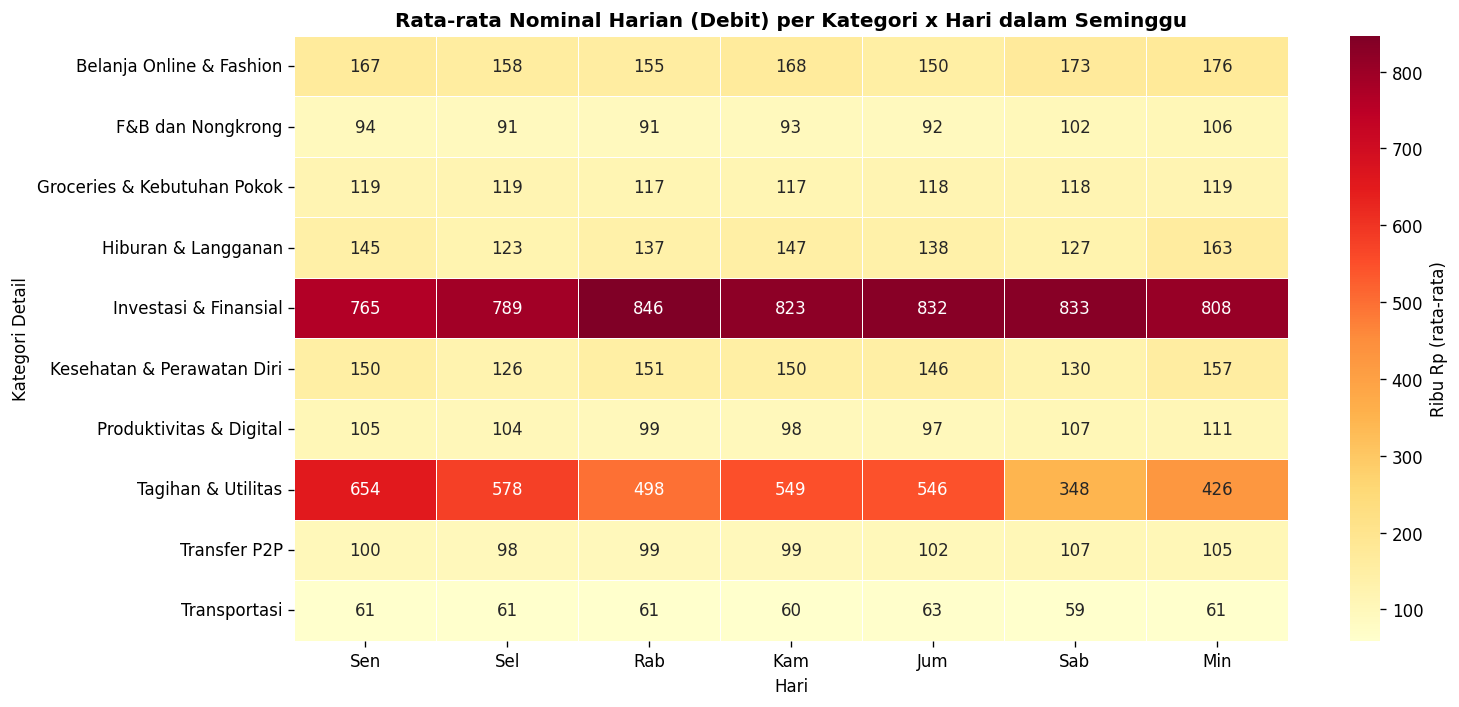

In [20]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_LABEL = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

pivot_harian = (
    daily_user_kat
    .groupby(['kategori_detail', 'hari_nama'])['total_nominal']
    .mean()
    .unstack('hari_nama')
    .reindex(columns=DAY_ORDER)
)
pivot_harian.columns = DAY_LABEL

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_harian / 1e3,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Ribu Rp (rata-rata)'},
    ax=ax
)
ax.set_title('Rata-rata Nominal Harian (Debit) per Kategori x Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

## 3. Frekuensi Transaksi per Minggu

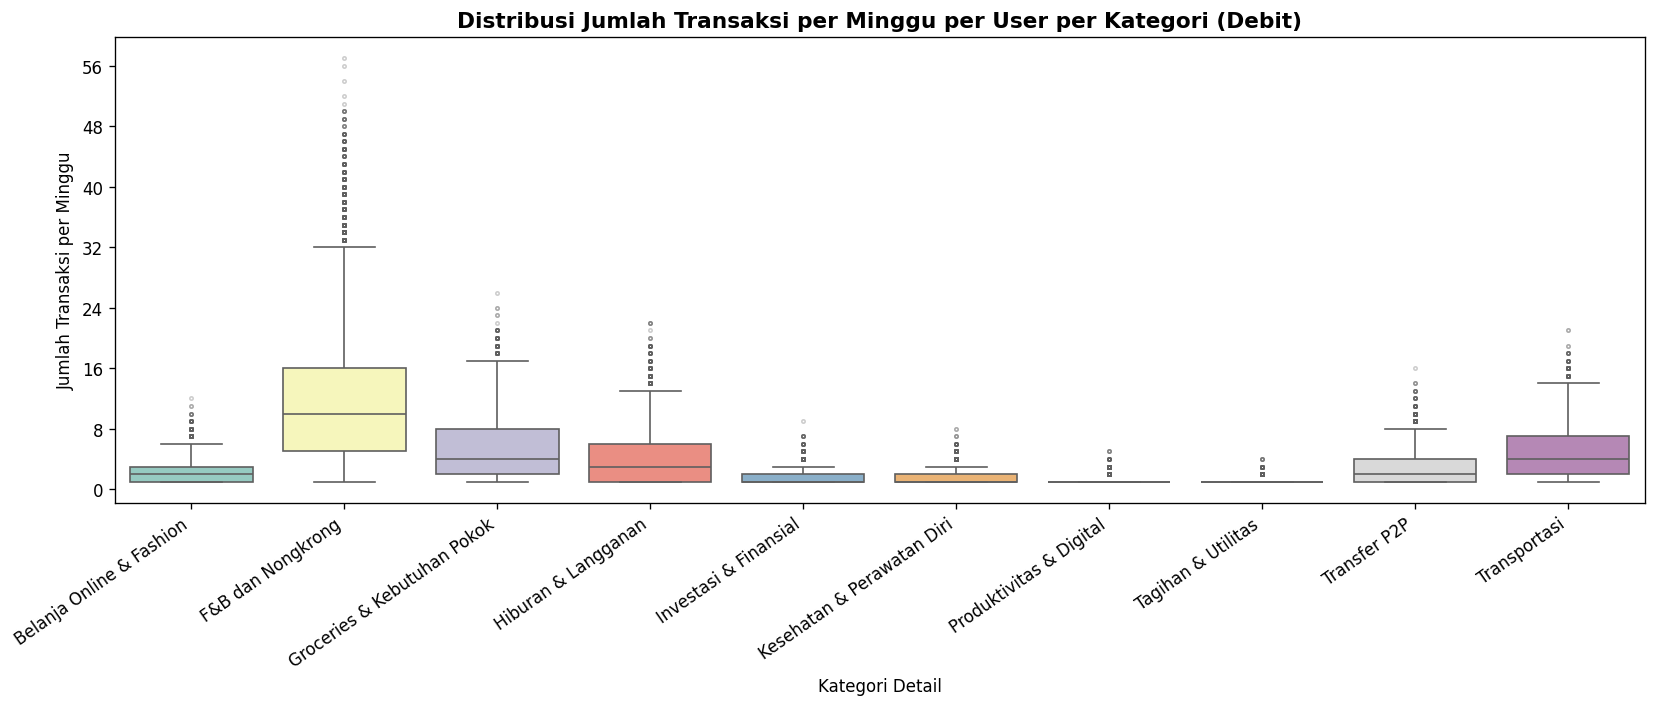


Statistik Jumlah Transaksi per Minggu per Kategori:


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"3,456.0",2.3,1.8,1.0,1.0,2.0,3.0,6.0,12.0
F&B dan Nongkrong,"9,648.0",12.0,9.5,1.0,5.0,10.0,16.0,33.0,57.0
Groceries & Kebutuhan Pokok,"8,367.0",5.3,4.2,1.0,2.0,4.0,8.0,14.0,26.0
Hiburan & Langganan,"5,958.0",4.1,3.6,1.0,1.0,3.0,6.0,12.0,22.0
Investasi & Finansial,"2,932.0",1.5,0.9,1.0,1.0,1.0,2.0,3.0,9.0
Kesehatan & Perawatan Diri,"4,378.0",1.6,0.9,1.0,1.0,1.0,2.0,3.0,8.0
Produktivitas & Digital,"1,945.0",1.3,0.6,1.0,1.0,1.0,1.0,2.0,5.0
Tagihan & Utilitas,"1,675.0",1.2,0.5,1.0,1.0,1.0,1.0,2.0,4.0
Transfer P2P,"5,128.0",2.9,2.2,1.0,1.0,2.0,4.0,7.0,16.0


In [21]:
weekly_user_kat = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['id_transaksi']
    .count()
    .reset_index(name='jumlah_trx')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=weekly_user_kat,
    x='kategori_detail',
    y='jumlah_trx',
    order=KATEGORI_ORDER,
    palette='Set3',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Jumlah Transaksi per Minggu per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Jumlah Transaksi per Minggu')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Jumlah Transaksi per Minggu per Kategori:')
weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].describe(
    percentiles=[.25, .5, .75, .95]
).round(2)

## 4. Tren Frekuensi per Minggu

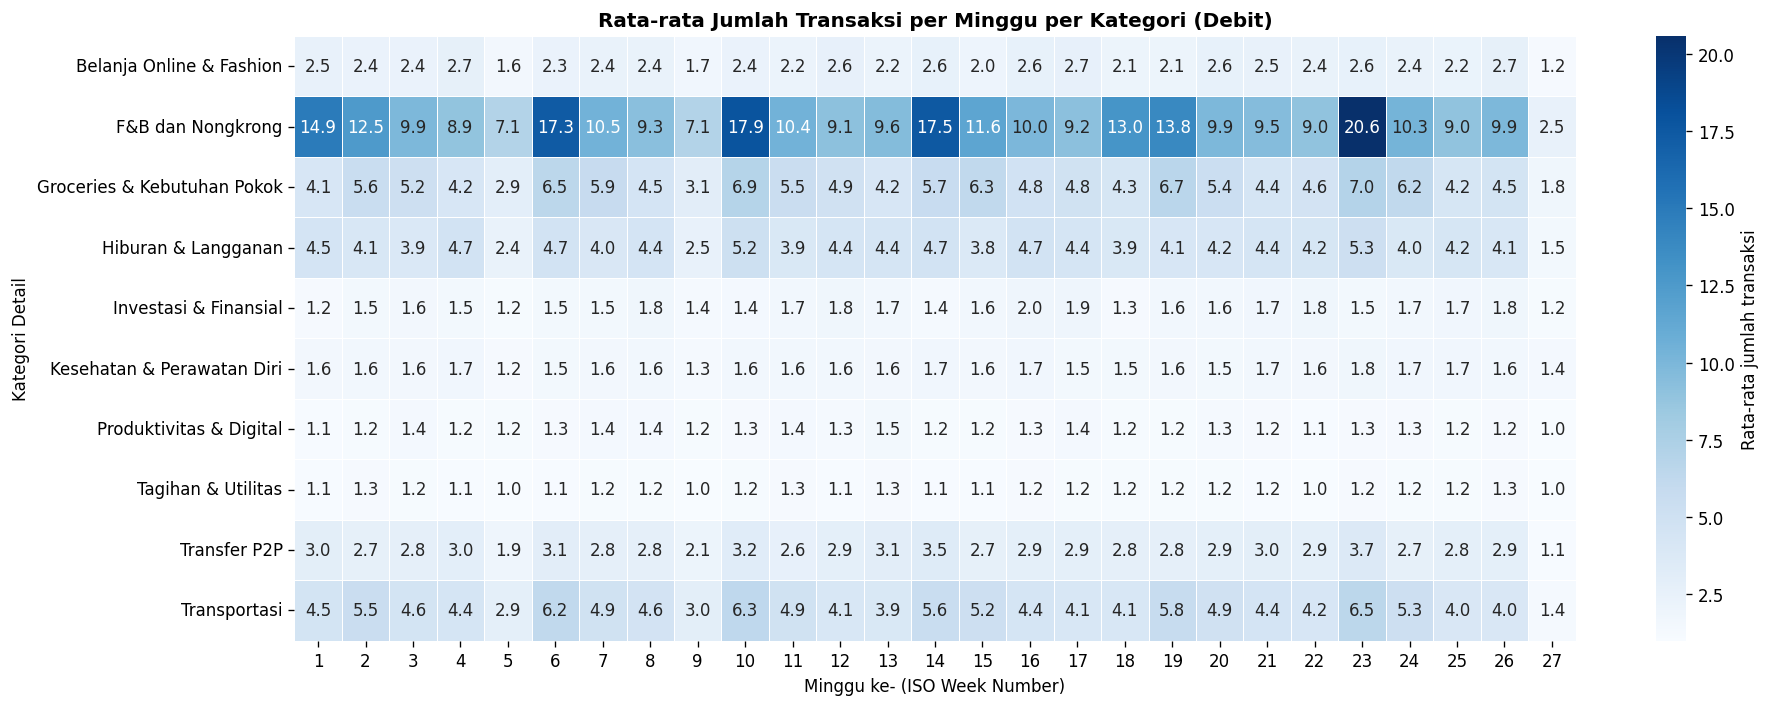

In [22]:
pivot_weekly = (
    weekly_user_kat
    .groupby(['kategori_detail', 'minggu_num'])['jumlah_trx']
    .mean()
    .unstack('minggu_num')
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_weekly,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Rata-rata jumlah transaksi'},
    ax=ax
)
ax.set_title('Rata-rata Jumlah Transaksi per Minggu per Kategori (Debit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

## 5. Nominal Mingguan — Tren & Distribusi

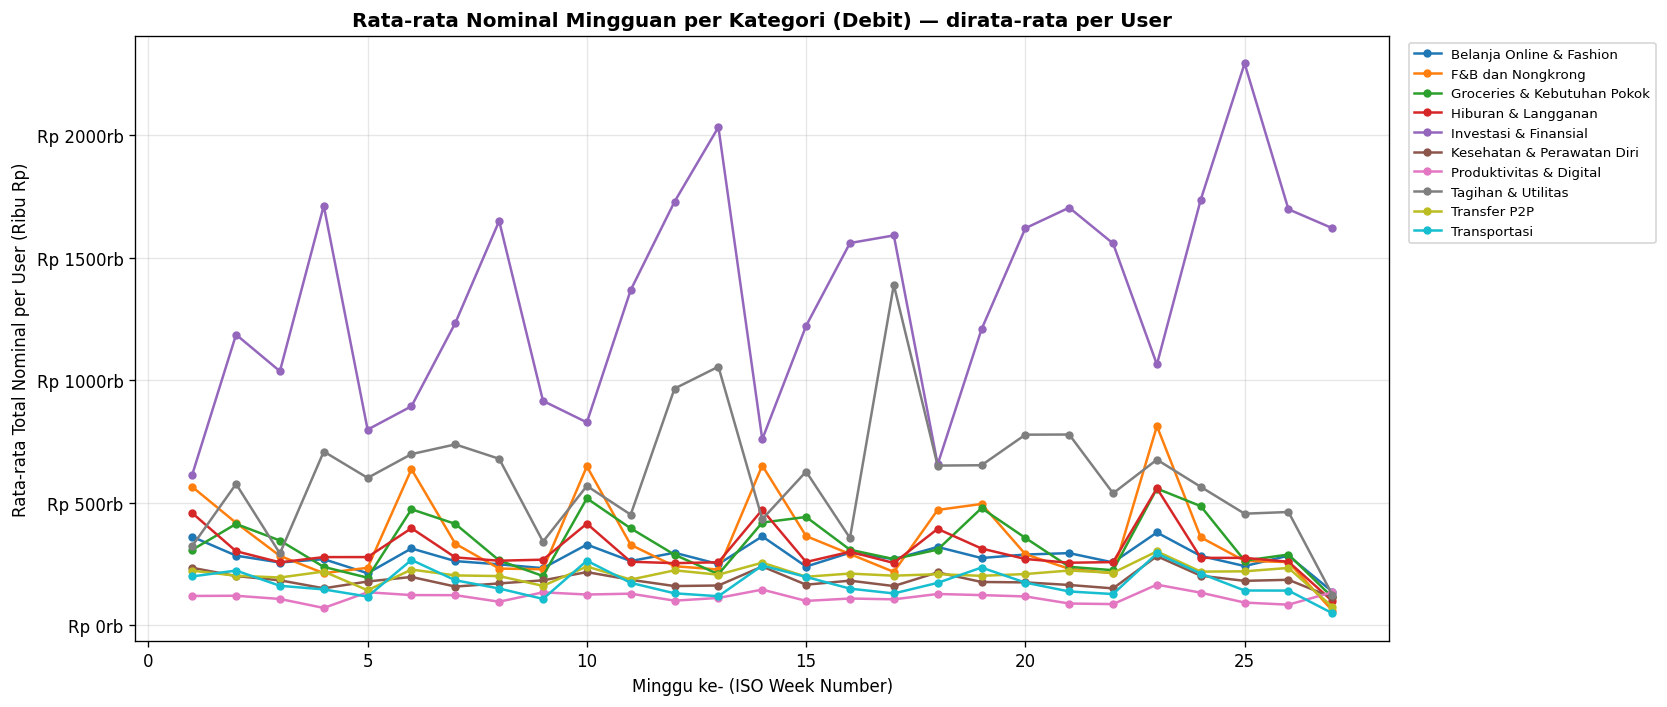

In [23]:
weekly_nominal = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

agg_weekly = (
    weekly_nominal
    .groupby(['minggu_num', 'kategori_detail'])['total_nominal']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', n_colors=len(KATEGORI_ORDER))
for i, kat in enumerate(KATEGORI_ORDER):
    subset = agg_weekly[agg_weekly['kategori_detail'] == kat]
    ax.plot(subset['minggu_num'], subset['total_nominal'] / 1e3,
            marker='o', markersize=4, label=kat, color=palette[i])

ax.set_title('Rata-rata Nominal Mingguan per Kategori (Debit) — dirata-rata per User', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Rata-rata Total Nominal per User (Ribu Rp)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

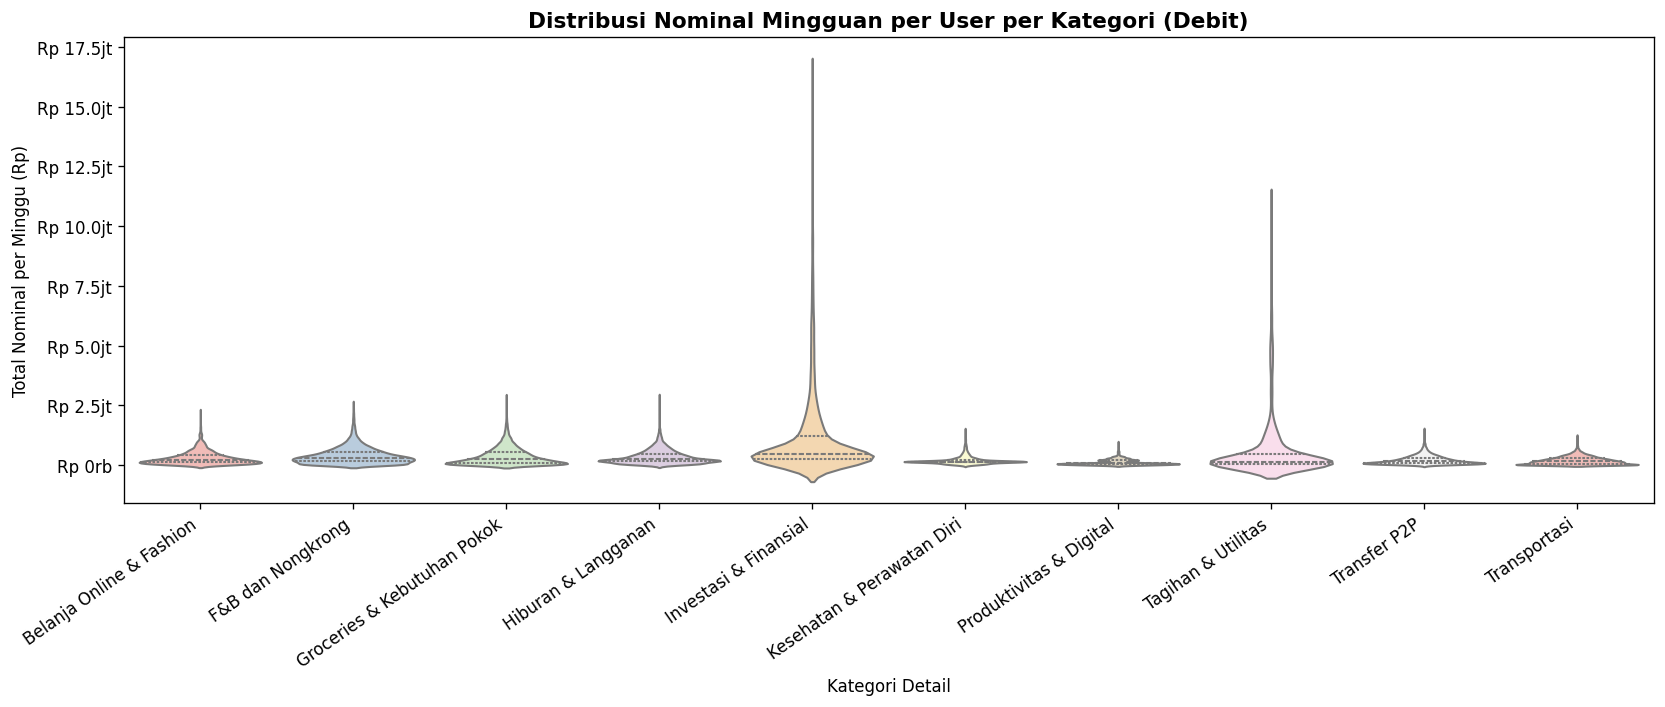

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=weekly_nominal,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribusi Nominal Mingguan per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Minggu (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 6. Rangkuman Statistik Mingguan

In [25]:
summary_nominal = weekly_nominal.groupby('kategori_detail')['total_nominal'].agg(
    median_nominal = 'median',
    mean_nominal   = 'mean',
    p75_nominal    = lambda x: x.quantile(0.75),
    p95_nominal    = lambda x: x.quantile(0.95),
)

summary_trx = weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].agg(
    median_trx = 'median',
    mean_trx   = 'mean',
    p75_trx    = lambda x: x.quantile(0.75),
    p95_trx    = lambda x: x.quantile(0.95),
)

summary = summary_nominal.join(summary_trx).round(1)
summary.columns = [
    'Median Nominal/Minggu', 'Mean Nominal/Minggu', 'P75 Nominal', 'P95 Nominal',
    'Median Trx/Minggu', 'Mean Trx/Minggu', 'P75 Trx', 'P95 Trx'
]

pd.set_option('display.float_format', '{:,.1f}'.format)
summary

,Median Nominal/Minggu,Mean Nominal/Minggu,P75 Nominal,P95 Nominal,Median Trx/Minggu,Mean Trx/Minggu,P75 Trx,P95 Trx
kategori_detail,,,,,,,,
Belanja Online & Fashion,"218,643.3","300,395.2","409,892.7","852,398.9",2.0,2.3,3.0,6.0
F&B dan Nongkrong,"319,951.3","402,022.2","558,165.7","1,067,217.5",10.0,12.0,16.0,33.0
Groceries & Kebutuhan Pokok,"250,758.7","367,492.1","533,615.9","1,103,594.5",4.0,5.3,8.0,14.0
Hiburan & Langganan,"258,951.4","350,161.0","482,459.2","916,508.5",3.0,4.1,6.0,12.0
Investasi & Finansial,"477,000.0","1,117,189.7","1,222,617.2","4,942,371.8",1.0,1.5,2.0,3.0
Kesehatan & Perawatan Diri,"150,000.0","205,733.2","233,426.4","568,246.2",1.0,1.6,2.0,3.0
Produktivitas & Digital,"78,698.9","124,233.5","200,000.0","350,000.0",1.0,1.3,1.0,2.0
Tagihan & Utilitas,"126,393.8","594,663.1","478,651.0","3,536,661.1",1.0,1.2,1.0,2.0
Transfer P2P,"160,414.6","216,660.3","305,193.7","573,744.7",2.0,2.9,4.0,7.0


## 7. Rincian per User

In [26]:
def fmt_nominal(x):
    if pd.isna(x) or x == 0:
        return '-'
    elif x >= 1_000_000:
        return f'Rp {x/1_000_000:.2f}jt'
    return f'Rp {x/1_000:.0f}rb'


def fmt_trx(x):
    if pd.isna(x) or x == 0:
        return '-'
    return str(int(x))


def user_weekly_table(user_id, df_debit):
    df_u = df_debit[df_debit['id_user'] == user_id].copy()

    grp = df_u.groupby(['kategori_detail', 'minggu_num']).agg(
        nominal=('nominal', 'sum'),
        trx=('id_transaksi', 'count')
    ).reset_index()

    weeks = sorted(grp['minggu_num'].unique())

    piv_nominal = grp.pivot(index='kategori_detail', columns='minggu_num', values='nominal').fillna(0)
    piv_trx     = grp.pivot(index='kategori_detail', columns='minggu_num', values='trx').fillna(0)

    frames = []
    for w in weeks:
        col_label = f'Minggu {w}'
        frames.append(piv_nominal[w].rename((col_label, 'Nominal')))
        frames.append(piv_trx[w].rename((col_label, 'Trx')))

    result = pd.concat(frames, axis=1)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.index.name = 'Kategori'

    display_df = result.copy().astype(object)
    for w in weeks:
        col_label = f'Minggu {w}'
        display_df[(col_label, 'Nominal')] = result[(col_label, 'Nominal')].map(fmt_nominal)
        display_df[(col_label, 'Trx')]     = result[(col_label, 'Trx')].map(fmt_trx)

    return display_df


# Pilih 2 user sebagai contoh
SAMPLE_USERS = ['USR-001', 'USR-002']

for uid in SAMPLE_USERS:
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'  USER: {uid}')
    print(sep)
    tbl = user_weekly_table(uid, df_debit)
    display(tbl)


  USER: USR-001


Minggu 1      Minggu 2      Minggu 5      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 345rb   2         -   -         -   -   
F&B dan Nongkrong            Rp 909rb  24  Rp 264rb   7  Rp 259rb   9   
Groceries & Kebutuhan Pokok    Rp 3rb   1   Rp 21rb   1         -   -   
Hiburan & Langganan          Rp 868rb   7   Rp 71rb   2  Rp 245rb   2   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 222rb   2         -   -         -   -   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -         -   -  Rp 243rb   1   
Transfer P2P                 Rp 249rb   3         -   -   Rp 49rb   1   
Transportasi                 Rp 246rb   7   Rp 64rb   1  Rp 316rb   1   

                             Minggu 6      Minggu 7      ...  Minggu 19      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion            -   -         -   -  ...          -   -   
F&B dan Nongkrong            Rp 357rb  15  Rp 165rb   5  ...   Rp 499rb  10   
Groceries & Kebutuhan Pokok  Rp 192rb   2  Rp 144rb   4  ...  Rp 1.05jt  13   
Hiburan & Langganan          Rp 439rb   3  Rp 201rb   3  ...   Rp 192rb   1   
Investasi & Finansial               -   -         -   -  ...          -   -   
Kesehatan & Perawatan Diri          -   -         -   -  ...          -   -   
Produktivitas & Digital             -   -         -   -  ...          -   -   
Tagihan & Utilitas             Rp 7rb   1         -   -  ...          -   -   
Transfer P2P                 Rp 212rb   3         -   -  ...   Rp 179rb   3   
Transportasi                 Rp 436rb   7  Rp 240rb   9  ...   Rp 115rb   3   

                            Minggu 20     Minggu 23     Minggu 24      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -         -   -         -   -   
F&B dan Nongkrong             Rp 83rb   2  Rp 305rb   9  Rp 791rb  15   
Groceries & Kebutuhan Pokok   Rp 46rb   3  Rp 461rb   7  Rp 863rb  14   
Hiburan & Langganan                 -   -  Rp 186rb   1         -   -   
Investasi & Finansial               -   -  Rp 313rb   1         -   -   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1         -   -   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                        -   -         -   -   Rp 86rb   1   
Transportasi                  Rp 25rb   1  Rp 113rb   4   Rp 76rb   4   

                            Minggu 25      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 130rb   3  
Groceries & Kebutuhan Pokok   Rp 62rb   2  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas            Rp 51rb   1  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 36 columns]


  USER: USR-002


Minggu 1      Minggu 5      Minggu 6      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 273rb   2         -   -         -   -   
F&B dan Nongkrong            Rp 591rb  22  Rp 141rb   4  Rp 569rb  17   
Groceries & Kebutuhan Pokok  Rp 201rb   5  Rp 125rb   2   Rp 40rb   2   
Hiburan & Langganan          Rp 831rb   4  Rp 588rb   4   Rp 71rb   2   
Investasi & Finansial               -   -  Rp 220rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -   Rp 52rb   1   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                  Rp 79rb   1  Rp 223rb   3   Rp 51rb   1   
Transportasi                  Rp 71rb   3   Rp 17rb   1  Rp 100rb   3   

                             Minggu 9     Minggu 10      ... Minggu 19      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion     Rp 214rb   1   Rp 10rb   1  ...         -   -   
F&B dan Nongkrong             Rp 56rb   3  Rp 810rb  20  ...  Rp 142rb   5   
Groceries & Kebutuhan Pokok         -   -  Rp 188rb   3  ...         -   -   
Hiburan & Langganan          Rp 359rb   4  Rp 249rb   2  ...         -   -   
Investasi & Finansial               -   -         -   -  ...         -   -   
Kesehatan & Perawatan Diri   Rp 173rb   2         -   -  ...         -   -   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Tagihan & Utilitas                  -   -         -   -  ...         -   -   
Transfer P2P                        -   -         -   -  ...         -   -   
Transportasi                   Rp 2rb   1  Rp 138rb   4  ...         -   -   

                            Minggu 21     Minggu 23     Minggu 24      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -  Rp 277rb   2         -   -   
F&B dan Nongkrong            Rp 416rb   6  Rp 907rb  27    Rp 5rb   1   
Groceries & Kebutuhan Pokok         -   -  Rp 112rb   4         -   -   
Hiburan & Langganan                 -   -  Rp 480rb   3         -   -   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri          -   -         -   -         -   -   
Produktivitas & Digital             -   -   Rp 15rb   1         -   -   
Tagihan & Utilitas                  -   -   Rp 38rb   1         -   -   
Transfer P2P                        -   -  Rp 292rb   3         -   -   
Transportasi                   Rp 5rb   1   Rp 74rb   4         -   -   

                            Minggu 26      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 151rb   5  
Groceries & Kebutuhan Pokok  Rp 159rb   1  
Hiburan & Langganan           Rp 48rb   1  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                 Rp 419rb   3  

[10 rows x 26 columns]

## 8. Pola per Persona & Segmen

In [27]:
SEGMEN_ORDER  = ['Mahasiswa', 'First Jobber', 'Profesional']
PERSONA_ORDER = ['Spendthrift', 'Unconflicted', 'Tightwad']

nasabah_info = df_nas.set_index('id_user')[
    ['segmen_demografi', 'persona_dasar', 'gaji_bulanan']
].to_dict('index')

SAMPLE_GRID = {
    (seg, per): df_nas.loc[
        (df_nas['segmen_demografi'] == seg) & (df_nas['persona_dasar'] == per),
        'id_user'
    ].iloc[0]
    for seg in SEGMEN_ORDER for per in PERSONA_ORDER
    if ((df_nas['segmen_demografi'] == seg) & (df_nas['persona_dasar'] == per)).any()
}

for segmen in SEGMEN_ORDER:
    print('▓' * 80)
    print(f'  SEGMEN: {segmen.upper()}')
    print('▓' * 80)
    for persona in PERSONA_ORDER:
        uid = SAMPLE_GRID.get((segmen, persona))
        if uid is None:
            continue
        info     = nasabah_info.get(uid, {})
        gaji     = info.get('gaji_bulanan', 0)
        gaji_fmt = f'Rp {gaji/1e6:.2f}jt' if gaji >= 1e6 else f'Rp {gaji/1e3:.0f}rb'
        print(f'\n  {persona:<14}  |  {uid}  |  Gaji: {gaji_fmt}')
        print('-' * 80)
        display(user_weekly_table(uid, df_debit))

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  SEGMEN: MAHASISWA
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Spendthrift     |  USR-156  |  Gaji: Rp 2.97jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2     Minggu 3      \
                              Nominal Trx   Nominal Trx  Nominal Trx   
Kategori                                                               
Belanja Online & Fashion     Rp 400rb   2         -   -        -   -   
F&B dan Nongkrong            Rp 887rb  22  Rp 328rb  10   Rp 6rb   1   
Groceries & Kebutuhan Pokok  Rp 375rb   6    Rp 5rb   1        -   -   
Hiburan & Langganan          Rp 303rb   3  Rp 143rb   1        -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -        -   -   
Produktivitas & Digital       Rp 79rb   1         -   -        -   -   
Tagihan & Utilitas                  -   -         -   -        -   -   
Transfer P2P                 Rp 430rb   5         -   -        -   -   
Transportasi                 Rp 275rb   3    Rp 3rb   1        -   -   

                             Minggu 5      Minggu 6      ...  Minggu 14      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion            -   -   Rp 10rb   1  ...    Rp 53rb   1   
F&B dan Nongkrong            Rp 286rb   6  Rp 593rb  19  ...  Rp 1.09jt  25   
Groceries & Kebutuhan Pokok  Rp 110rb   1   Rp 67rb   2  ...    Rp 23rb   1   
Hiburan & Langganan          Rp 614rb   4  Rp 328rb   5  ...   Rp 773rb   6   
Kesehatan & Perawatan Diri          -   -  Rp 513rb   2  ...   Rp 150rb   1   
Produktivitas & Digital             -   -         -   -  ...   Rp 215rb   1   
Tagihan & Utilitas                  -   -         -   -  ...          -   -   
Transfer P2P                  Rp 87rb   1  Rp 174rb   2  ...   Rp 510rb   5   
Transportasi                  Rp 45rb   2  Rp 142rb   5  ...   Rp 153rb   3   

                            Minggu 18     Minggu 19      Minggu 23      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion     Rp 928rb   4         -   -   Rp 220rb   2   
F&B dan Nongkrong            Rp 398rb  17  Rp 292rb   9   Rp 499rb  16   
Groceries & Kebutuhan Pokok   Rp 96rb   2  Rp 124rb   2   Rp 339rb   3   
Hiburan & Langganan          Rp 762rb   7         -   -  Rp 1.24jt   8   
Kesehatan & Perawatan Diri          -   -         -   -          -   -   
Produktivitas & Digital             -   -         -   -          -   -   
Tagihan & Utilitas                  -   -         -   -    Rp 70rb   2   
Transfer P2P                 Rp 138rb   2  Rp 145rb   3   Rp 191rb   3   
Transportasi                  Rp 74rb   3   Rp 14rb   2   Rp 411rb   8   

                            Minggu 26      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                   Rp 3rb   1  

[9 rows x 30 columns]


  Unconflicted    |  USR-074  |  Gaji: Rp 3.21jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2      Minggu 5      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion             -   -         -   -         -   -   
F&B dan Nongkrong             Rp 320rb  12  Rp 558rb  13         -   -   
Groceries & Kebutuhan Pokok     Rp 6rb   1   Rp 39rb   2   Rp 39rb   1   
Hiburan & Langganan          Rp 1.02jt   4         -   -  Rp 237rb   2   
Investasi & Finansial         Rp 321rb   1         -   -         -   -   
Kesehatan & Perawatan Diri     Rp 30rb   1         -   -         -   -   
Produktivitas & Digital       Rp 385rb   2   Rp 28rb   1         -   -   
Tagihan & Utilitas                   -   -         -   -         -   -   
Transfer P2P                   Rp 59rb   1  Rp 142rb   2  Rp 115rb   1   
Transportasi                   Rp 21rb   3  Rp 273rb   4  Rp 253rb   1   

                             Minggu 6      Minggu 7      ... Minggu 19      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion            -   -         -   -  ...   Rp 14rb   1   
F&B dan Nongkrong            Rp 874rb  21  Rp 232rb   5  ...  Rp 381rb  13   
Groceries & Kebutuhan Pokok  Rp 119rb   3  Rp 100rb   2  ...   Rp 21rb   1   
Hiburan & Langganan          Rp 114rb   2  Rp 475rb   3  ...   Rp 51rb   1   
Investasi & Finansial               -   -         -   -  ...         -   -   
Kesehatan & Perawatan Diri    Rp 29rb   1         -   -  ...   Rp 39rb   1   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Tagihan & Utilitas                  -   -         -   -  ...         -   -   
Transfer P2P                 Rp 241rb   3         -   -  ...  Rp 116rb   1   
Transportasi                  Rp 73rb   4  Rp 304rb   5  ...  Rp 137rb   5   

                            Minggu 22      Minggu 23     Minggu 24      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -   Rp 338rb   1         -   -   
F&B dan Nongkrong            Rp 199rb   5   Rp 868rb  23  Rp 394rb   7   
Groceries & Kebutuhan Pokok         -   -   Rp 336rb   4         -   -   
Hiburan & Langganan           Rp 59rb   1  Rp 1.50jt   6  Rp 452rb   3   
Investasi & Finansial               -   -          -   -         -   -   
Kesehatan & Perawatan Diri          -   -   Rp 263rb   3         -   -   
Produktivitas & Digital       Rp 70rb   1    Rp 70rb   1         -   -   
Tagihan & Utilitas                  -   -    Rp 49rb   1         -   -   
Transfer P2P                  Rp 61rb   1   Rp 414rb   6  Rp 194rb   3   
Transportasi                 Rp 275rb   4   Rp 279rb  10  Rp 109rb   3   

                            Minggu 25      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong             Rp 10rb   2  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 36 columns]


  Tightwad        |  USR-105  |  Gaji: Rp 1.60jt
--------------------------------------------------------------------------------


...

Minggu 1      Minggu 2      Minggu 3      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 367rb   4  Rp 253rb   3  Rp 756rb   6   
F&B dan Nongkrong            Rp 650rb  27  Rp 617rb  36  Rp 836rb  36   
Groceries & Kebutuhan Pokok  Rp 107rb   3  Rp 324rb   7  Rp 396rb   8   
Hiburan & Langganan          Rp 345rb   9  Rp 478rb  10  Rp 920rb  18   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 326rb   3   Rp 93rb   1  Rp 327rb   3   
Produktivitas & Digital             -   -         -   -  Rp 291rb   2   
Tagihan & Utilitas                  -   -   Rp 56rb   1  Rp 248rb   2   
Transfer P2P                 Rp 590rb   7  Rp 485rb   6  Rp 578rb   6   
Transportasi                 Rp 116rb   3  Rp 580rb  17  Rp 234rb   7   

                             Minggu 4      Minggu 5      ...  Minggu 23      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion     Rp 345rb   3   Rp 27rb   2  ...   Rp 873rb   7   
F&B dan Nongkrong            Rp 619rb  35  Rp 652rb  25  ...   Rp 927rb  38   
Groceries & Kebutuhan Pokok  Rp 262rb   6  Rp 355rb   5  ...   Rp 163rb   4   
Hiburan & Langganan          Rp 671rb  10  Rp 506rb   9  ...  Rp 1.32jt  15   
Investasi & Finansial        Rp 170rb   1         -   -  ...          -   -   
Kesehatan & Perawatan Diri   Rp 161rb   3  Rp 266rb   3  ...   Rp 240rb   2   
Produktivitas & Digital      Rp 250rb   2         -   -  ...          -   -   
Tagihan & Utilitas                  -   -   Rp 39rb   1  ...          -   -   
Transfer P2P                 Rp 189rb   3  Rp 436rb   8  ...   Rp 738rb  10   
Transportasi                 Rp 716rb  13  Rp 447rb  10  ...   Rp 617rb  16   

                            Minggu 24     Minggu 25      Minggu 26      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion     Rp 295rb   3  Rp 380rb   2   Rp 479rb   6   
F&B dan Nongkrong            Rp 522rb  30  Rp 920rb  32   Rp 695rb  30   
Groceries & Kebutuhan Pokok  Rp 223rb   3  Rp 182rb   5   Rp 281rb   5   
Hiburan & Langganan          Rp 769rb  11  Rp 146rb   4   Rp 496rb  11   
Investasi & Finansial        Rp 565rb   1         -   -  Rp 1.53jt   2   
Kesehatan & Perawatan Diri   Rp 635rb   2  Rp 313rb   1   Rp 206rb   2   
Produktivitas & Digital       Rp 50rb   1   Rp 72rb   1    Rp 50rb   1   
Tagihan & Utilitas                  -   -  Rp 233rb   2          -   -   
Transfer P2P                 Rp 548rb   7  Rp 494rb   8   Rp 250rb   4   
Transportasi                 Rp 445rb  17  Rp 709rb  13   Rp 516rb   7   

                            Minggu 27      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion     Rp 121rb   1  
F&B dan Nongkrong             Rp 90rb   5  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan          Rp 182rb   2  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 54 columns]


  Unconflicted    |  USR-451  |  Gaji: Rp 14.40jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2       Minggu 3      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion     Rp 220rb   2  Rp 347rb   3     Rp 9rb   1   
F&B dan Nongkrong            Rp 334rb  16  Rp 385rb  18   Rp 415rb  17   
Groceries & Kebutuhan Pokok  Rp 153rb   3   Rp 34rb   1   Rp 558rb   9   
Hiburan & Langganan          Rp 289rb   7   Rp 87rb   1    Rp 53rb   1   
Investasi & Finansial        Rp 753rb   1         -   -          -   -   
Kesehatan & Perawatan Diri   Rp 232rb   3   Rp 15rb   1   Rp 155rb   2   
Produktivitas & Digital       Rp 38rb   1         -   -          -   -   
Tagihan & Utilitas           Rp 346rb   2         -   -  Rp 1.25jt   1   
Transfer P2P                 Rp 350rb   6  Rp 577rb   6   Rp 275rb   3   
Transportasi                 Rp 107rb   5   Rp 94rb   4   Rp 107rb   7   

                             Minggu 4      Minggu 5      ...  Minggu 23      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion      Rp 96rb   1  Rp 161rb   2  ...          -   -   
F&B dan Nongkrong            Rp 173rb   8  Rp 377rb  14  ...   Rp 344rb  15   
Groceries & Kebutuhan Pokok   Rp 64rb   3  Rp 160rb   5  ...   Rp 208rb   4   
Hiburan & Langganan          Rp 289rb   4  Rp 136rb   3  ...   Rp 375rb   4   
Investasi & Finansial               -   -  Rp 246rb   1  ...  Rp 2.53jt   2   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1  ...   Rp 215rb   2   
Produktivitas & Digital             -   -         -   -  ...          -   -   
Tagihan & Utilitas                  -   -   Rp 53rb   1  ...   Rp 671rb   2   
Transfer P2P                 Rp 223rb   4   Rp 32rb   1  ...   Rp 400rb   5   
Transportasi                 Rp 311rb  11  Rp 258rb   8  ...   Rp 236rb   7   

                             Minggu 24      Minggu 25     Minggu 26      \
                               Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion       Rp 31rb   1          -   -  Rp 549rb   3   
F&B dan Nongkrong             Rp 507rb  12   Rp 476rb  17  Rp 423rb  17   
Groceries & Kebutuhan Pokok   Rp 140rb   3   Rp 185rb   6  Rp 433rb   4   
Hiburan & Langganan           Rp 560rb   8   Rp 154rb   3  Rp 180rb   4   
Investasi & Finansial        Rp 2.31jt   1  Rp 1.54jt   1         -   -   
Kesehatan & Perawatan Diri    Rp 775rb   3          -   -  Rp 130rb   1   
Produktivitas & Digital              -   -          -   -   Rp 70rb   1   
Tagihan & Utilitas                   -   -          -   -   Rp 43rb   1   
Transfer P2P                    Rp 7rb   1   Rp 304rb   4  Rp 158rb   2   
Transportasi                  Rp 149rb   9   Rp 294rb   9  Rp 211rb   9   

                            Minggu 27      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong             Rp 83rb   3  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri   Rp 150rb   1  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                  Rp 57rb   1  
Transportasi                   Rp 9rb   1  

[10 rows x 54 columns]


  Tightwad        |  USR-476  |  Gaji: Rp 9.01jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2      Minggu 3      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion             -   -         -   -         -   -   
F&B dan Nongkrong              Rp 61rb   4  Rp 239rb   9  Rp 107rb   7   
Groceries & Kebutuhan Pokok   Rp 519rb   6  Rp 442rb   8  Rp 338rb   7   
Hiburan & Langganan                  -   -         -   -         -   -   
Investasi & Finansial        Rp 5.65jt   2  Rp 335rb   1         -   -   
Kesehatan & Perawatan Diri    Rp 150rb   1         -   -         -   -   
Produktivitas & Digital              -   -         -   -         -   -   
Tagihan & Utilitas                   -   -   Rp 40rb   1         -   -   
Transfer P2P                         -   -  Rp 105rb   1         -   -   
Transportasi                  Rp 131rb   3  Rp 319rb   8  Rp 306rb   7   

                             Minggu 4      Minggu 5      ...  Minggu 23      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion            -   -         -   -  ...   Rp 215rb   2   
F&B dan Nongkrong             Rp 80rb   4         -   -  ...   Rp 287rb  11   
Groceries & Kebutuhan Pokok  Rp 130rb   2  Rp 283rb   5  ...   Rp 889rb  17   
Hiburan & Langganan                 -   -         -   -  ...          -   -   
Investasi & Finansial               -   -         -   -  ...  Rp 1.64jt   3   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1  ...   Rp 300rb   2   
Produktivitas & Digital             -   -         -   -  ...          -   -   
Tagihan & Utilitas                  -   -         -   -  ...          -   -   
Transfer P2P                        -   -         -   -  ...          -   -   
Transportasi                  Rp 54rb   4   Rp 48rb   3  ...   Rp 362rb   4   

                            Minggu 24      Minggu 25     Minggu 26      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -          -   -         -   -   
F&B dan Nongkrong            Rp 110rb   5   Rp 147rb   9  Rp 188rb   9   
Groceries & Kebutuhan Pokok  Rp 730rb  15   Rp 653rb  13  Rp 547rb  12   
Hiburan & Langganan                 -   -          -   -  Rp 162rb   2   
Investasi & Finansial        Rp 299rb   1  Rp 1.14jt   2  Rp 776rb   2   
Kesehatan & Perawatan Diri          -   -    Rp 54rb   1         -   -   
Produktivitas & Digital       Rp 27rb   1          -   -         -   -   
Tagihan & Utilitas            Rp 17rb   1          -   -         -   -   
Transfer P2P                 Rp 142rb   2          -   -   Rp 70rb   1   
Transportasi                 Rp 246rb   6   Rp 158rb   5   Rp 40rb   2   

                            Minggu 27      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 15rb   1  

[10 rows x 52 columns]

## 9. Rasio Kategori Besar per Persona

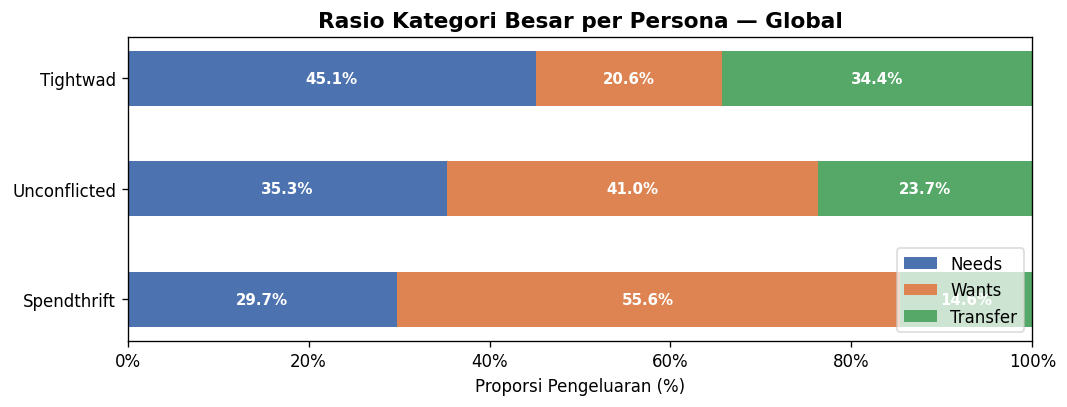

kategori_besar  Needs  Wants  Transfer
persona_dasar                         
Spendthrift      29.7   55.6      14.6
Unconflicted     35.3   41.0      23.7
Tightwad         45.1   20.6      34.4


In [28]:
# Merge debit dengan persona_dasar dari df_nas
df_persona = df_debit.merge(
    df_nas[['id_user', 'persona_dasar']],
    on='id_user', how='left'
)

# Agregasi: total nominal per persona × kategori_besar
ratio_global = (
    df_persona
    .groupby(['persona_dasar', 'kategori_besar'])['nominal']
    .sum()
    .reset_index()
)

# Hitung persentase dalam tiap persona (total = 100%)
ratio_global['pct'] = (
    ratio_global['nominal']
    / ratio_global.groupby('persona_dasar')['nominal'].transform('sum')
    * 100
)

# Pivot: baris = persona, kolom = kategori_besar
PERSONA_ORDER  = ['Spendthrift', 'Unconflicted', 'Tightwad']
KAT_BESAR_ORDER = ['Needs', 'Wants', 'Transfer']
COLORS          = {'Needs': '#4C72B0', 'Wants': '#DD8452', 'Transfer': '#55A868'}

pivot_global = (
    ratio_global
    .pivot(index='persona_dasar', columns='kategori_besar', values='pct')
    .reindex(index=PERSONA_ORDER, columns=KAT_BESAR_ORDER)
    .fillna(0)
)

# Plot stacked horizontal bar
fig, ax = plt.subplots(figsize=(9, 3.5))

left = [0] * len(PERSONA_ORDER)
for kat in KAT_BESAR_ORDER:
    vals = pivot_global[kat].values
    bars = ax.barh(PERSONA_ORDER, vals, left=left,
                   color=COLORS[kat], label=kat, height=0.5)
    for bar, val, lft in zip(bars, vals, left):
        if val >= 3:
            ax.text(
                lft + val / 2, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
    left = [l + v for l, v in zip(left, vals)]

ax.set_xlim(0, 100)
ax.set_xlabel('Proporsi Pengeluaran (%)')
ax.set_title('Rasio Kategori Besar per Persona — Global', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.7)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(pivot_global.round(1).to_string())

## 10. Rasio per Persona per Segmen

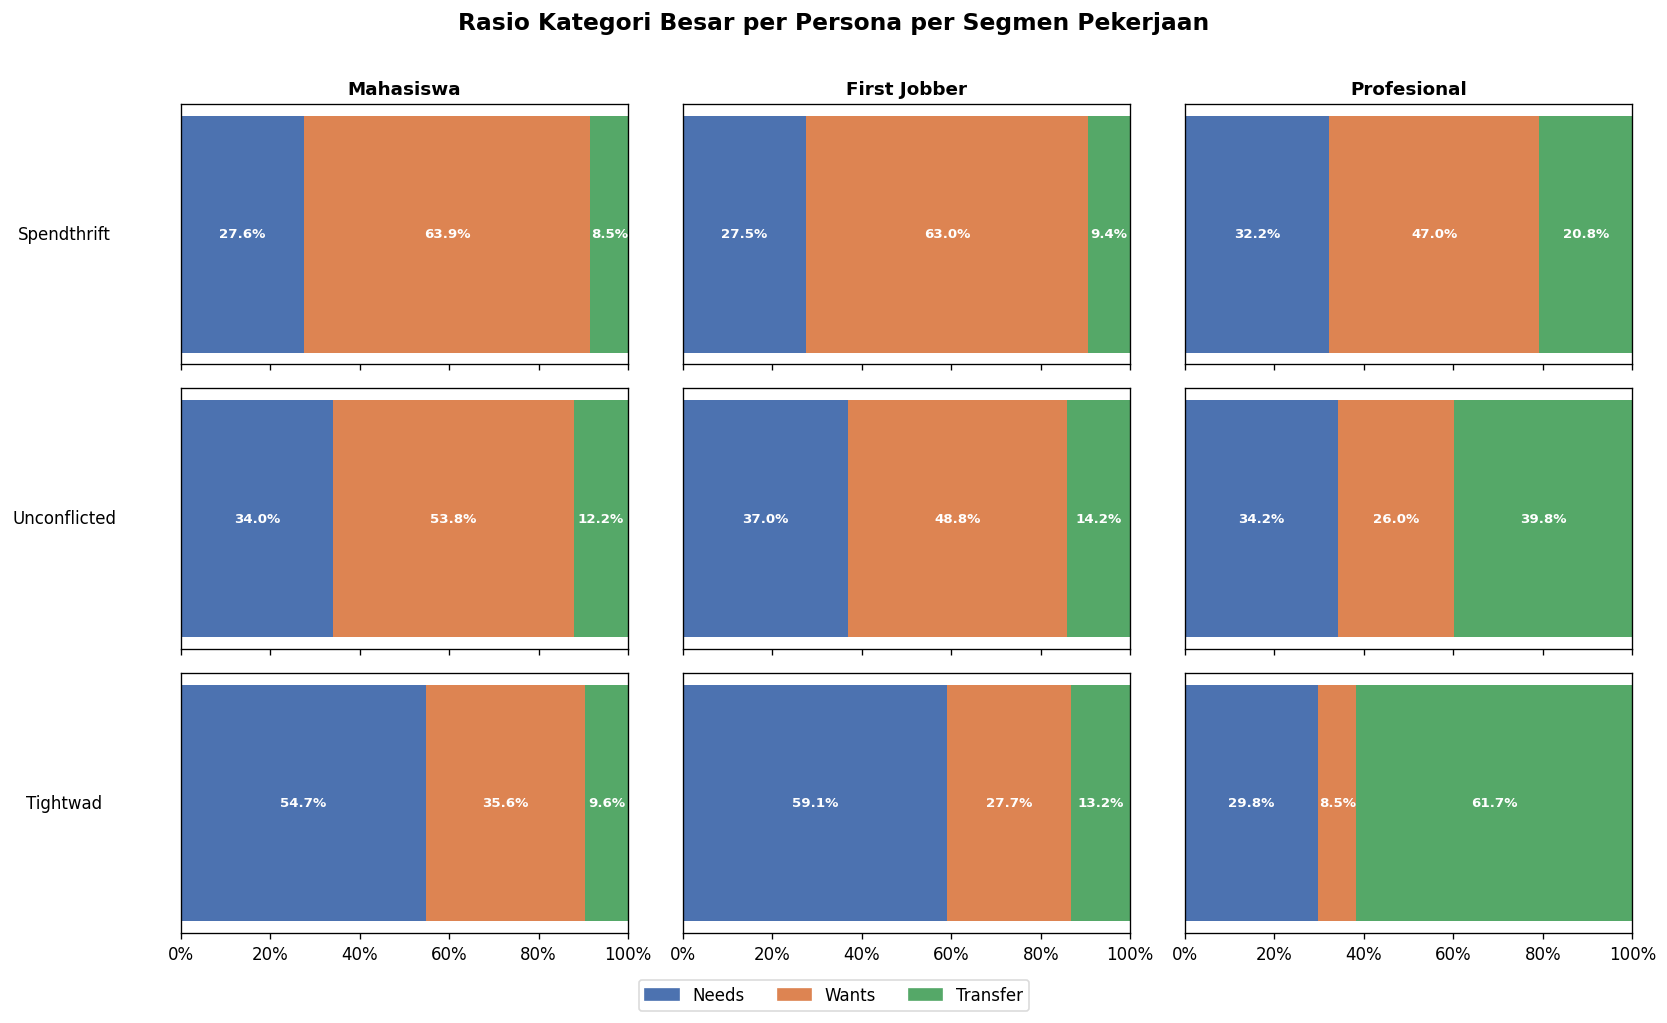

kategori_besar                  Needs  Wants  Transfer
segmen_demografi persona_dasar                        
Mahasiswa        Spendthrift     27.6   63.9       8.5
                 Unconflicted    34.0   53.8      12.2
                 Tightwad        54.7   35.6       9.6
First Jobber     Spendthrift     27.5   63.0       9.4
                 Unconflicted    37.0   48.8      14.2
                 Tightwad        59.1   27.7      13.2
Profesional      Spendthrift     32.2   47.0      20.8
                 Unconflicted    34.2   26.0      39.8
                 Tightwad        29.8    8.5      61.7


In [29]:
# Merge debit dengan persona + segmen
df_seg_persona = df_debit.merge(
    df_nas[['id_user', 'persona_dasar', 'segmen_demografi']],
    on='id_user', how='left'
)

# Agregasi: total nominal per segmen × persona × kategori_besar
ratio_seg = (
    df_seg_persona
    .groupby(['segmen_demografi', 'persona_dasar', 'kategori_besar'])['nominal']
    .sum()
    .reset_index()
)

# Persentase dalam tiap segmen × persona
ratio_seg['pct'] = (
    ratio_seg['nominal']
    / ratio_seg.groupby(['segmen_demografi', 'persona_dasar'])['nominal'].transform('sum')
    * 100
)

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']

# Grid 3 kolom (segmen) × 3 baris (persona)
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(14, 8),
    sharey=False, sharex=True
)
fig.suptitle(
    'Rasio Kategori Besar per Persona per Segmen Pekerjaan',
    fontsize=14, fontweight='bold', y=1.01
)

for col_idx, segmen in enumerate(SEGMEN_ORDER):
    for row_idx, persona in enumerate(PERSONA_ORDER):
        ax = axes[row_idx][col_idx]

        subset = ratio_seg[
            (ratio_seg['segmen_demografi'] == segmen) &
            (ratio_seg['persona_dasar']    == persona)
        ].set_index('kategori_besar')['pct'].reindex(KAT_BESAR_ORDER).fillna(0)

        left = 0
        for kat in KAT_BESAR_ORDER:
            val = subset[kat]
            ax.barh([0], [val], left=left,
                    color=COLORS[kat], label=kat if (row_idx == 0 and col_idx == 0) else '_',
                    height=0.5)
            if val >= 4:
                ax.text(
                    left + val / 2, 0,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold'
                )
            left += val

        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

        # Header kolom (segmen) — hanya baris pertama
        if row_idx == 0:
            ax.set_title(segmen, fontsize=11, fontweight='bold')

        # Label baris (persona) — hanya kolom pertama
        if col_idx == 0:
            ax.set_ylabel(persona, fontsize=10, rotation=0,
                          labelpad=70, va='center')

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color=COLORS[k]) for k in KAT_BESAR_ORDER
    ],
    labels=KAT_BESAR_ORDER,
    loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04),
    framealpha=0.7, fontsize=10
)

plt.tight_layout()
plt.show()

# Tabel ringkasan numerik
tbl = (
    ratio_seg
    .pivot_table(
        index=['segmen_demografi', 'persona_dasar'],
        columns='kategori_besar',
        values='pct'
    )
    .reindex(index=pd.MultiIndex.from_product([SEGMEN_ORDER, PERSONA_ORDER],
                                               names=['segmen_demografi', 'persona_dasar']),
             columns=KAT_BESAR_ORDER)
    .round(1)
)
print(tbl.to_string())

## 11. Correlation Matrix — Fitur Input Autoencoder

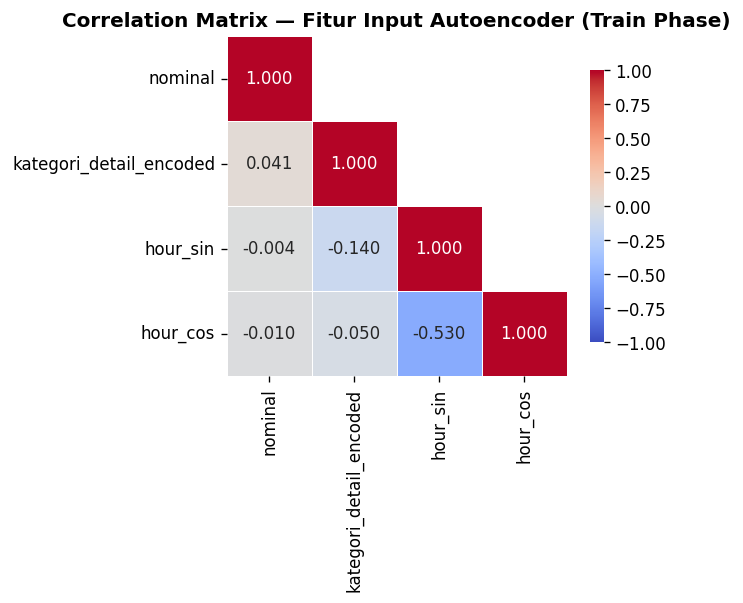

Pasangan dengan |r| > 0.5 (multicollinearity concern):
  hour_sin × hour_cos: r=-0.530


In [30]:
FEATURE_COLS = ['nominal', 'kategori_detail_encoded', 'hour_sin', 'hour_cos']

feat_train = (
    df_debit[df_debit['phase'] == 'train'][FEATURE_COLS]
    .dropna()
)
corr = feat_train.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Matrix — Fitur Input Autoencoder (Train Phase)', fontweight='bold')
plt.tight_layout()
plt.show()

pairs = [
    (corr.columns[i], corr.columns[j], corr.iloc[i, j])
    for i in range(len(corr.columns))
    for j in range(i + 1, len(corr.columns))
    if abs(corr.iloc[i, j]) > 0.5
]
print('Pasangan dengan |r| > 0.5 (multicollinearity concern):')
print('Tidak ada.' if not pairs else '\n'.join(f'  {a} × {b}: r={v:.3f}' for a, b, v in pairs))

## 12. Distribusi Proxy MAE: Anomali vs Normal

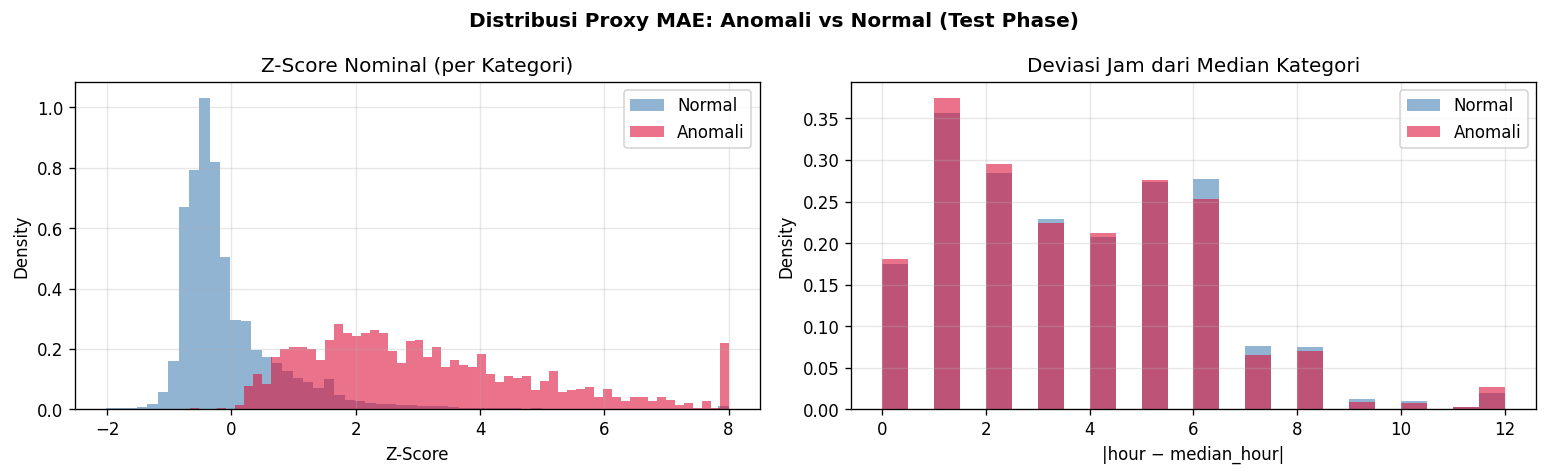

Z-Score Nominal (anomali vs normal):


,count,mean,std,min,25%,50%,75%,max
label_anomali,,,,,,,,
0,"42,608.0",-0.0,1.0,-2.0,-0.6,-0.3,0.2,11.8
1,"1,317.0",3.1,2.0,-0.7,1.7,2.7,4.1,16.3



Deviasi Jam (anomali vs normal):


,count,mean,std,min,25%,50%,75%,max
label_anomali,,,,,,,,
0,"42,608.0",3.5,2.5,0.0,1.0,3.0,5.0,13.0
1,"1,317.0",3.5,2.5,0.0,1.0,3.0,5.0,13.0


In [31]:
train_stats = (
    df_debit[df_debit['phase'] == 'train']
    .groupby('kategori_detail')['nominal']
    .agg(mu='mean', sigma='std')
)
train_hour_med = (
    df_debit[df_debit['phase'] == 'train']
    .groupby('kategori_detail')['hour']
    .median()
    .rename('hour_med')
)

df_test = (
    df_debit[df_debit['phase'] == 'test']
    .join(train_stats,    on='kategori_detail')
    .join(train_hour_med, on='kategori_detail')
    .copy()
)
df_test['nominal_z'] = (df_test['nominal'] - df_test['mu']) / df_test['sigma'].clip(lower=1)
df_test['hour_dev']  = (df_test['hour'] - df_test['hour_med']).abs()

PALETTE = {0: ('Normal', 'steelblue'), 1: ('Anomali', 'crimson')}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lbl, (name, color) in PALETTE.items():
    sub = df_test[df_test['label_anomali'] == lbl]
    axes[0].hist(sub['nominal_z'].clip(-3, 8),  bins=60, alpha=0.6, color=color, label=name, density=True)
    axes[1].hist(sub['hour_dev'].clip(0, 12),   bins=24, alpha=0.6, color=color, label=name, density=True)

axes[0].set(title='Z-Score Nominal (per Kategori)', xlabel='Z-Score', ylabel='Density')
axes[1].set(title='Deviasi Jam dari Median Kategori', xlabel='|hour − median_hour|', ylabel='Density')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle('Distribusi Proxy MAE: Anomali vs Normal (Test Phase)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Z-Score Nominal (anomali vs normal):')
display(df_test.groupby('label_anomali')['nominal_z'].describe().round(2))
print('\nDeviasi Jam (anomali vs normal):')
display(df_test.groupby('label_anomali')['hour_dev'].describe().round(2))

## 13. Separation Score per Kategori (Cohen's d)

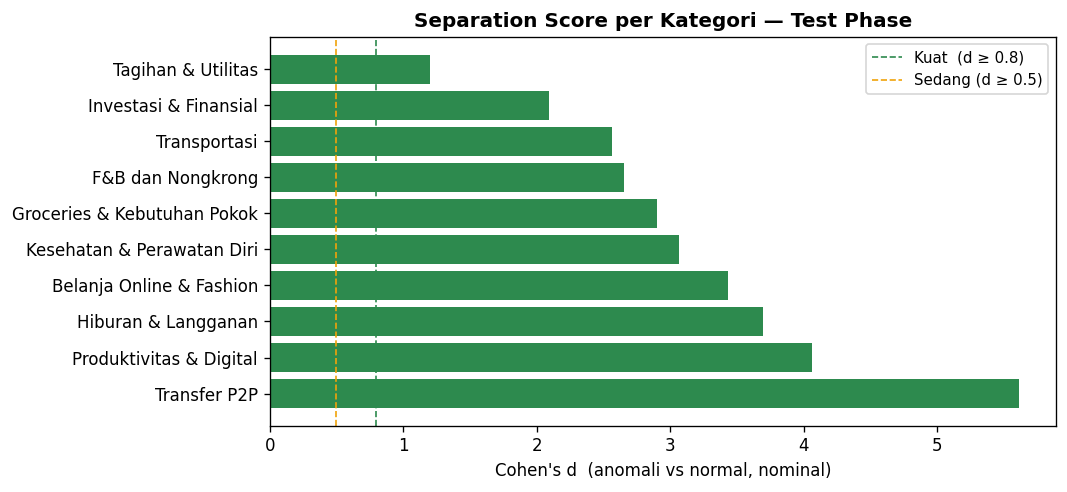

                   kategori  n_anomali  n_normal   mean_anom  mean_norm  cohens_d
               Transfer P2P         75      2382   294,521.0   73,933.6       5.6
    Produktivitas & Digital         13       414   508,660.3  100,348.4       4.1
        Hiburan & Langganan        128      3835   334,117.8   82,772.6       3.7
   Belanja Online & Fashion         34      1234   474,346.0  123,161.7       3.4
 Kesehatan & Perawatan Diri         29      1115   485,867.1  133,683.1       3.1
Groceries & Kebutuhan Pokok        230      7148   284,926.5   68,327.8       2.9
          F&B dan Nongkrong        582     18535   136,935.9   32,487.2       2.7
               Transportasi        195      6871   149,193.2   37,954.1       2.6
      Investasi & Finansial         22       741 3,410,881.6  819,341.7       2.1
         Tagihan & Utilitas          9       333 1,629,709.6  450,239.9       1.2


In [32]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled_var = ((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2)
    return (a.mean() - b.mean()) / np.sqrt(pooled_var) if pooled_var > 0 else np.nan


test_debit = df_debit[df_debit['phase'] == 'test']

sep_df = pd.DataFrame([
    {
        'kategori'  : kat,
        'n_anomali' : (sub['label_anomali'] == 1).sum(),
        'n_normal'  : (sub['label_anomali'] == 0).sum(),
        'mean_anom' : sub.loc[sub['label_anomali'] == 1, 'nominal'].mean(),
        'mean_norm' : sub.loc[sub['label_anomali'] == 0, 'nominal'].mean(),
        'cohens_d'  : cohens_d(
            sub.loc[sub['label_anomali'] == 1, 'nominal'].values,
            sub.loc[sub['label_anomali'] == 0, 'nominal'].values,
        ),
    }
    for kat, sub in test_debit.groupby('kategori_detail')
]).dropna(subset=['cohens_d']).sort_values('cohens_d', ascending=False).reset_index(drop=True)

bar_colors = [
    '#2d8a4e' if d >= 0.8 else '#f0a30a' if d >= 0.5 else '#c0392b'
    for d in sep_df['cohens_d']
]

fig, ax = plt.subplots(figsize=(9, max(4, len(sep_df) * 0.42)))
ax.barh(sep_df['kategori'], sep_df['cohens_d'], color=bar_colors)
ax.axvline(0.8, color='#2d8a4e', linestyle='--', lw=1, label="Kuat  (d ≥ 0.8)")
ax.axvline(0.5, color='#f0a30a', linestyle='--', lw=1, label="Sedang (d ≥ 0.5)")
ax.set_xlabel("Cohen's d  (anomali vs normal, nominal)")
ax.set_title("Separation Score per Kategori — Test Phase", fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(sep_df[['kategori', 'n_anomali', 'n_normal', 'mean_anom', 'mean_norm', 'cohens_d']]
      .round(2).to_string(index=False))